In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

C:\Users\TERA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
data_dir = r"D:\ahmed\did it\data"
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 6978 files belonging to 4 classes.
Using 5583 files for training.
Found 6978 files belonging to 4 classes.
Using 1395 files for validation.
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']


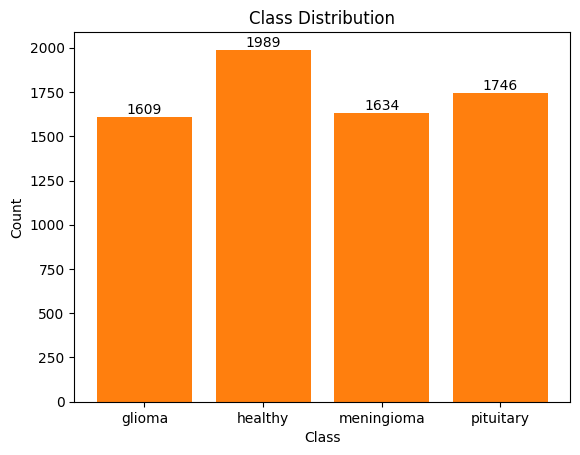

In [5]:
import os
import numpy as np

class_counts = []

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts.append(count)

import matplotlib.pyplot as plt

plt.bar(class_names, class_counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.bar_label(plt.bar(class_names, class_counts))
plt.show()

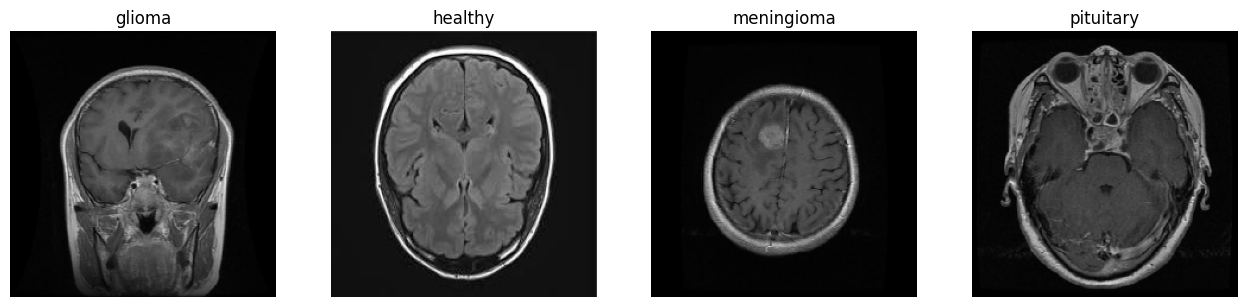

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

def loop(data_dir, classes):
    plt.figure(figsize=(20, 20))

    for i, clas in enumerate(classes):
        folder_name = os.path.join(data_dir, clas)
        folder = os.listdir(folder_name)

        if len(folder) == 0:
            continue

        first_img_path = os.path.join(folder_name, folder[0])

        img = image.load_img(first_img_path, target_size=(224, 224))
        img_arr = image.img_to_array(img) / 255

        plt.subplot(5, 5, i + 1)
        plt.imshow(img_arr)
        plt.title(clas)
        plt.axis('off')

    plt.show()

loop(data_dir, class_names)